Proyecto Curso I – Especialización Machine
Learning Engineering 

Estudiante: Valesca Fuenzalida Sánchez

**Dataset:** https://www.kaggle.com/code/faressayah/ibm-hr-analytics-employee-attrition-performance
**Archivo:** `WA_Fn-UseC_-HR-Employee-Attrition.csv` (7.043 × 21).

**Estructura.** Cada fila es un trabajador. Las 35 columnas se agrupan así:

## Diccionario de Variables

- **Identificador**: `EmployeeNumber`.

- **Demográficas**: `Age`, `Gender`, `Education`, `EducationField`, `MaritalStatus`, `DistanceFromHome`.

- **Sociales / Bienestar**: `BusinessTravel`, `EnvironmentSatisfaction`, `JobInvolvement`, `RelationshipSatisfaction`, `WorkLifeBalance`, `OverTime`.

- **Laborales**: `Department`, `JobRole`, `JobLevel`, `MonthlyIncome`, `DailyRate`, `HourlyRate`, `MonthlyRate`, `PerformanceRating`, `PercentSalaryHike`, `TrainingTimesLastYear`, `NumCompaniesWorked`, `YearsAtCompany`, `YearsInCurrentRole`, `YearsSinceLastPromotion`, `YearsWithCurrManager`, `StockOptionLevel`, `EmployeeCount`, `StandardHours`.

- **Target**: `Attrition` (Yes / No).

**Problema:** clasificación binaria — predecir la rotación de trabajadores utilizando variables demográficas, laborales y de desempeño. 
1. convierte `TotalCharges` a numérico y descarta las filas con NaN,
2. mapea `Attrition` a 1/0.

In [139]:
import pandas as pd

df = pd.read_csv("../data/WA_Fn-UseC_-HR-Employee-Attrition.csv")

df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [140]:
df.shape

(1470, 35)

In [141]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [142]:
df.isnull().sum()

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

# Exploración inicial

El dataset contiene 1470 registros y 35 variables.

Se identifican variables numéricas y categóricas.

No se observan valores nulos en las variables analizadas.

#### Descriptivo Variables Categóricas

In [143]:
import pandas as pd
import matplotlib.pyplot as plt

# Seleccionar variables categóricas/object
cat_cols = df.select_dtypes(include="object").columns

print("Variables categóricas:")
print(cat_cols)

# Estadística descriptiva categórica
df[cat_cols].describe().T

Variables categóricas:
Index(['Attrition', 'BusinessTravel', 'Department', 'EducationField', 'Gender',
       'JobRole', 'MaritalStatus', 'Over18', 'OverTime'],
      dtype='object')


,count,unique,top,freq
Attrition,1470,2,No,1233
BusinessTravel,1470,3,Travel_Rarely,1043
Department,1470,3,Research & Development,961
EducationField,1470,6,Life Sciences,606
Gender,1470,2,Male,882
JobRole,1470,9,Sales Executive,326
MaritalStatus,1470,3,Married,673
Over18,1470,1,Y,1470
OverTime,1470,2,No,1054


In [144]:
for col in cat_cols:
    print("\n" + "="*60)
    print(f"Variable: {col}")
    print(df[col].value_counts())
    print("\nPorcentajes:")
    print(df[col].value_counts(normalize=True) * 100)


Variable: Attrition
Attrition
No     1233
Yes     237
Name: count, dtype: int64

Porcentajes:
Attrition
No     83.877551
Yes    16.122449
Name: proportion, dtype: float64

Variable: BusinessTravel
BusinessTravel
Travel_Rarely        1043
Travel_Frequently     277
Non-Travel            150
Name: count, dtype: int64

Porcentajes:
BusinessTravel
Travel_Rarely        70.952381
Travel_Frequently    18.843537
Non-Travel           10.204082
Name: proportion, dtype: float64

Variable: Department
Department
Research & Development    961
Sales                     446
Human Resources            63
Name: count, dtype: int64

Porcentajes:
Department
Research & Development    65.374150
Sales                     30.340136
Human Resources            4.285714
Name: proportion, dtype: float64

Variable: EducationField
EducationField
Life Sciences       606
Medical             464
Marketing           159
Technical Degree    132
Other                82
Human Resources      27
Name: count, dtype: int64

P

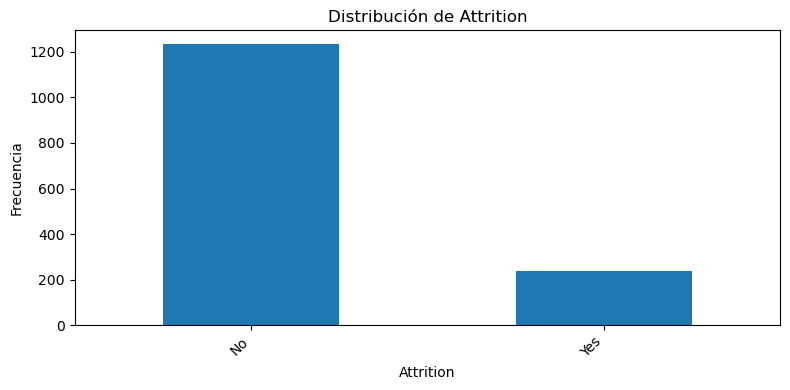

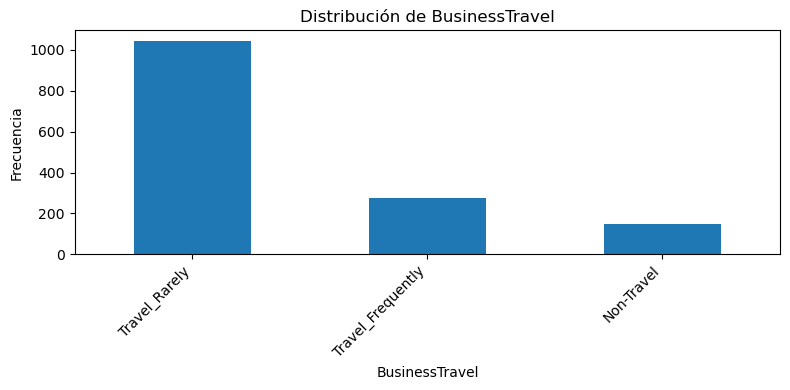

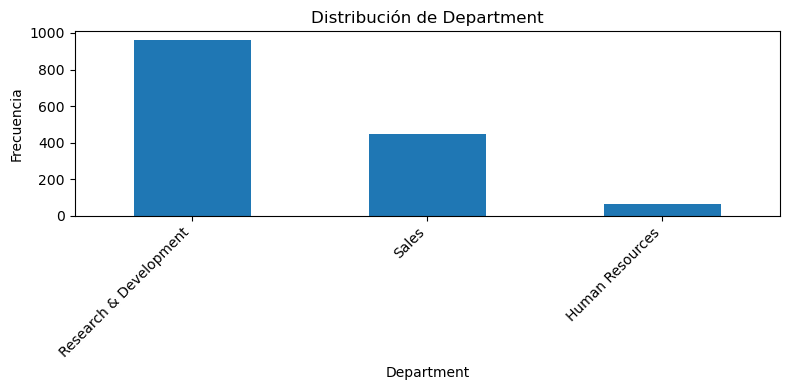

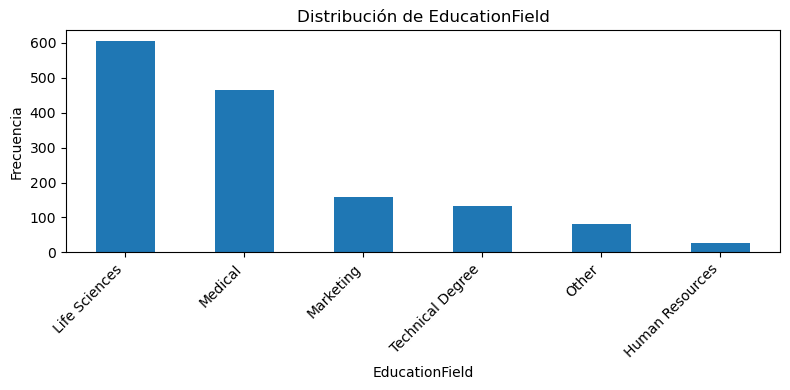

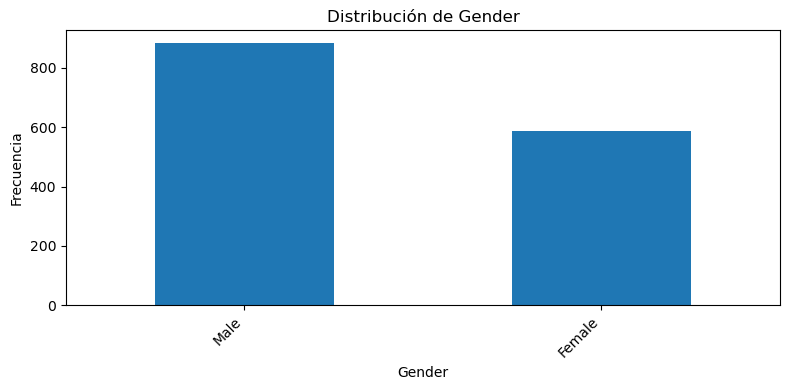

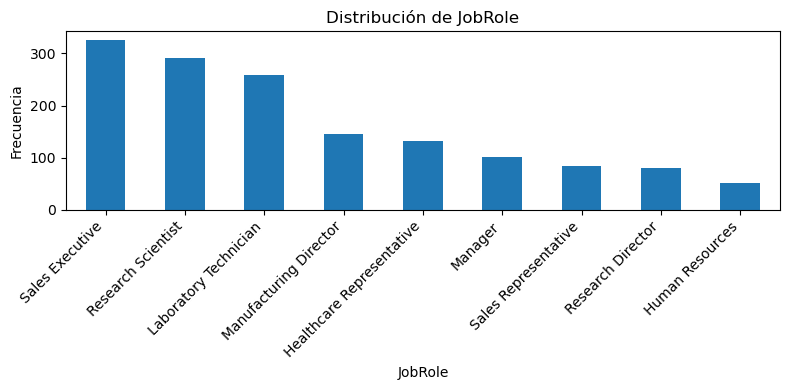

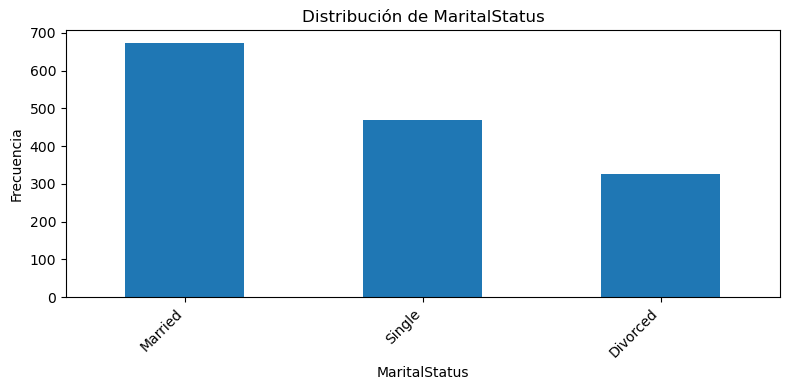

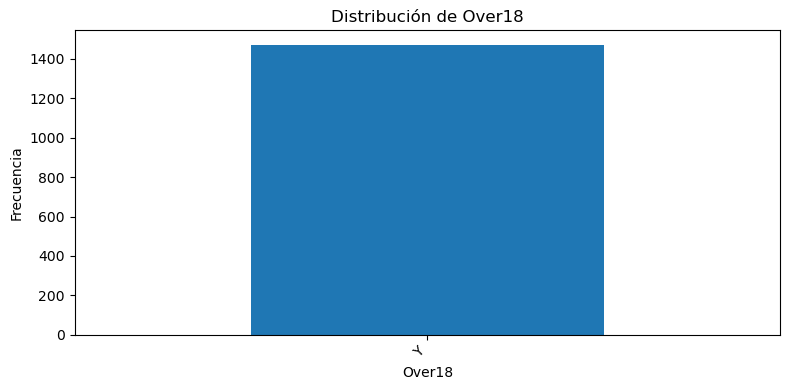

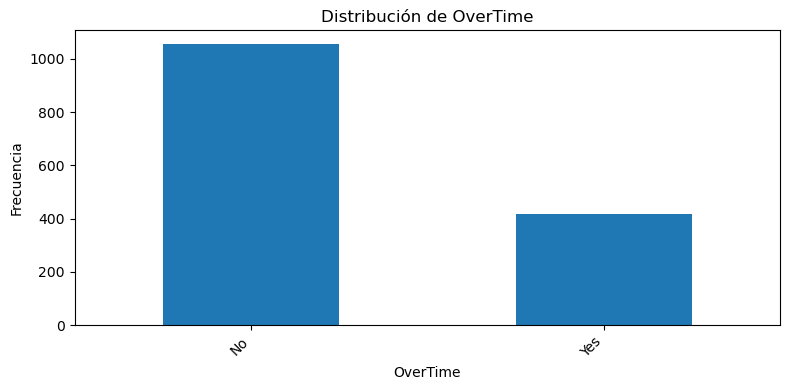

In [145]:
for col in cat_cols:
    plt.figure(figsize=(8, 4))
    
    df[col].value_counts().plot(kind="bar")
    
    plt.title(f"Distribución de {col}")
    plt.xlabel(col)
    plt.ylabel("Frecuencia")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

Interpretación: Al menos 5 de 8 variables categóricas se encuentran con desbalance, tomando especial atención la variable "y" con una participación aproximada de 80% - 20%. 

##### Descriptivo Variables Numéricas


In [146]:
num_cols = df.select_dtypes(include=["int64", "float64"]).columns

df[num_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
Age,1470.0,36.923810,9.135373,18.0,30.00,36.0,43.00,60.0
DailyRate,1470.0,802.485714,403.509100,102.0,465.00,802.0,1157.00,1499.0
DistanceFromHome,1470.0,9.192517,8.106864,1.0,2.00,7.0,14.00,29.0
Education,1470.0,2.912925,1.024165,1.0,2.00,3.0,4.00,5.0
EmployeeCount,1470.0,1.000000,0.000000,1.0,1.00,1.0,1.00,1.0
EmployeeNumber,1470.0,1024.865306,602.024335,1.0,491.25,1020.5,1555.75,2068.0
EnvironmentSatisfaction,1470.0,2.721769,1.093082,1.0,2.00,3.0,4.00,4.0
HourlyRate,1470.0,65.891156,20.329428,30.0,48.00,66.0,83.75,100.0
JobInvolvement,1470.0,2.729932,0.711561,1.0,2.00,3.0,3.00,4.0
JobLevel,1470.0,2.063946,1.106940,1.0,1.00,2.0,3.00,5.0


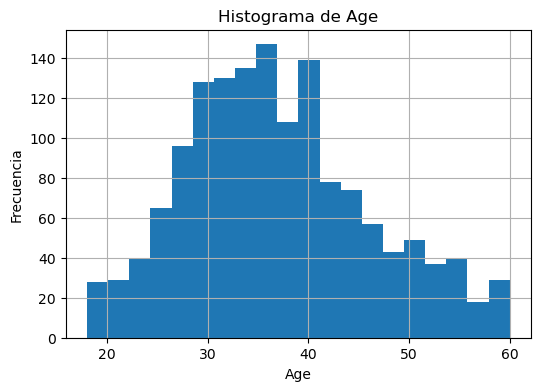

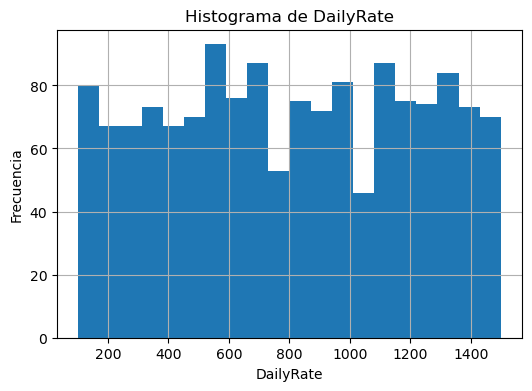

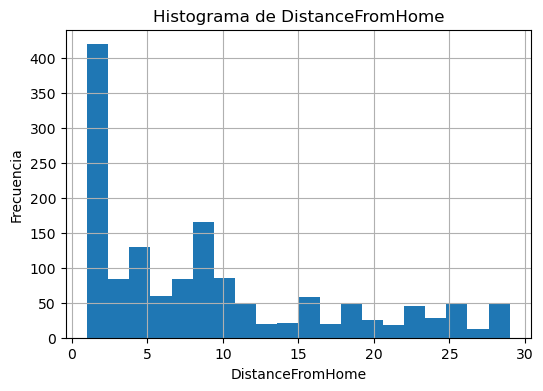

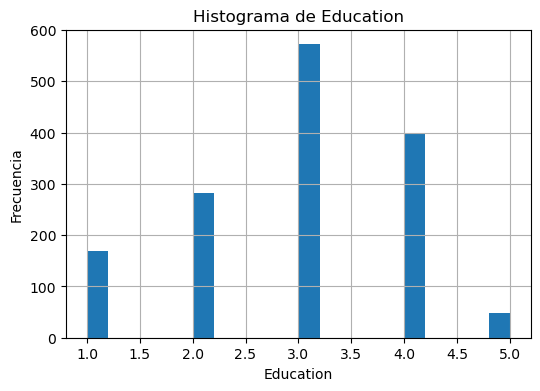

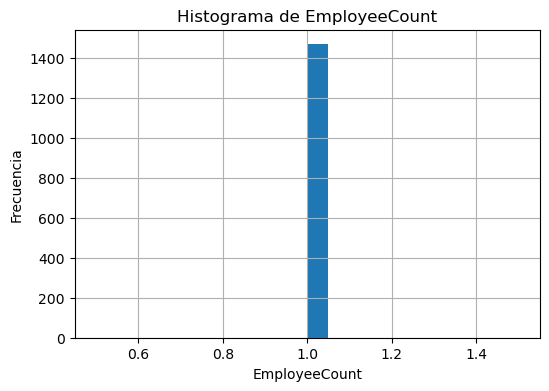

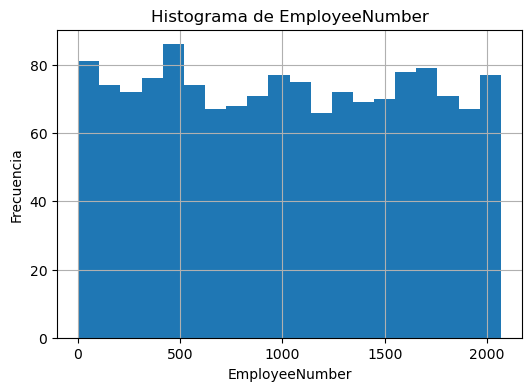

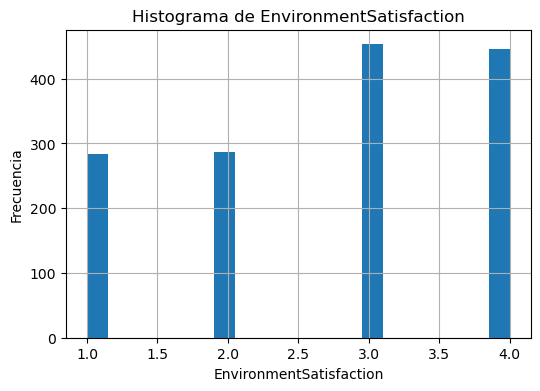

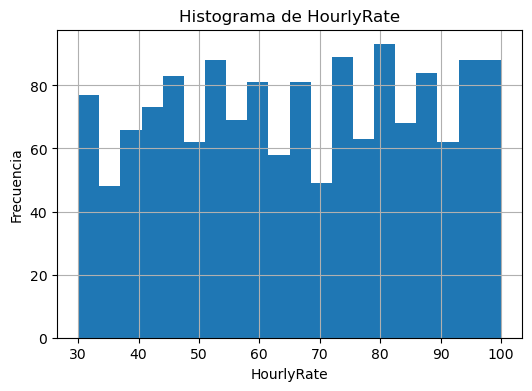

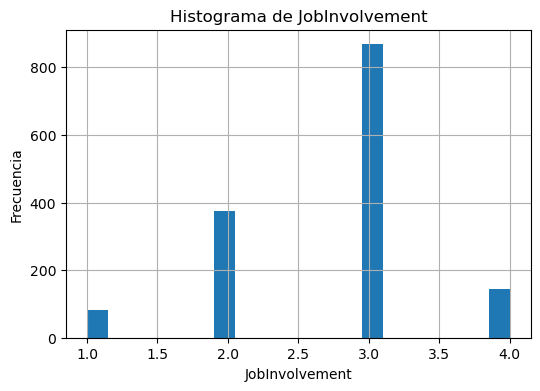

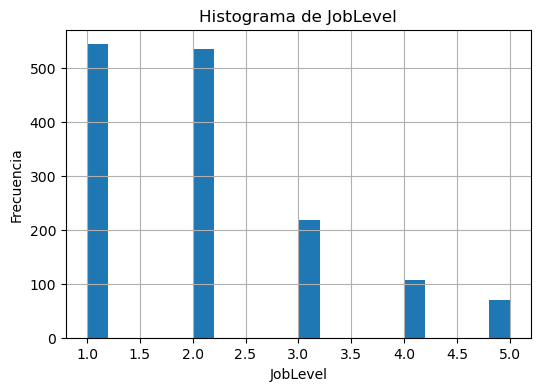

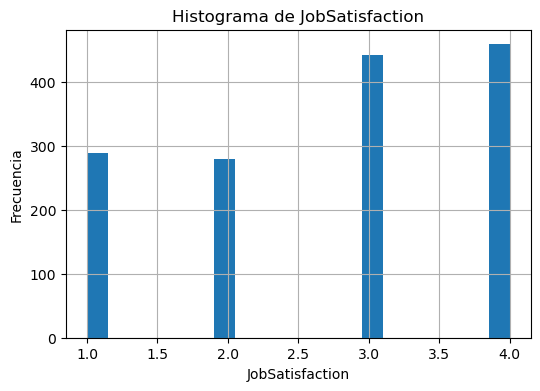

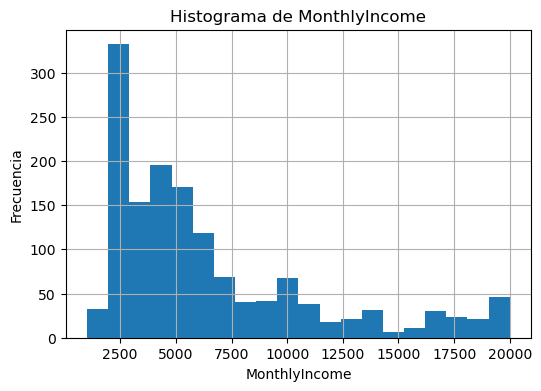

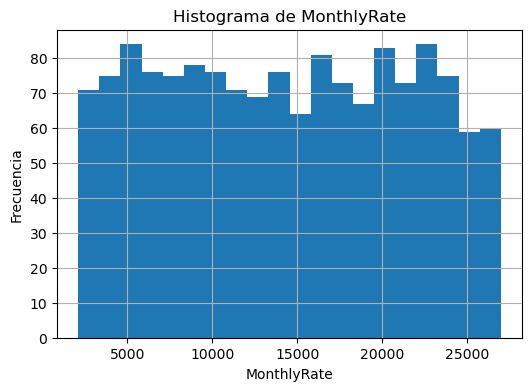

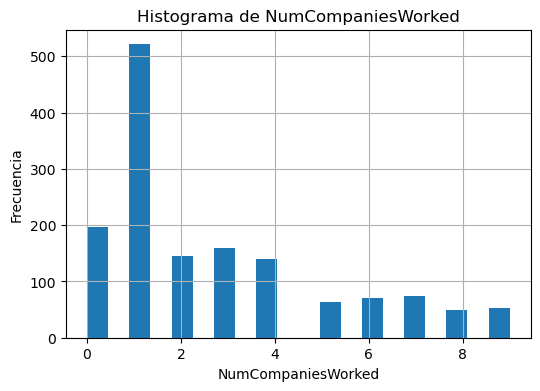

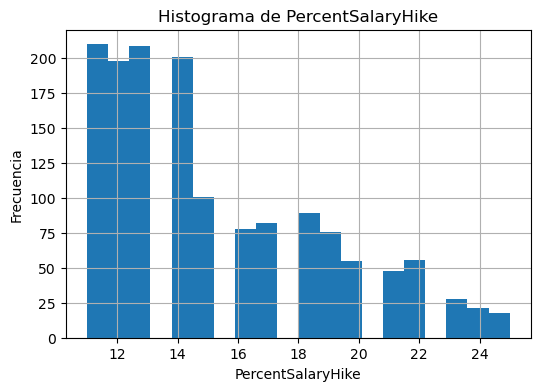

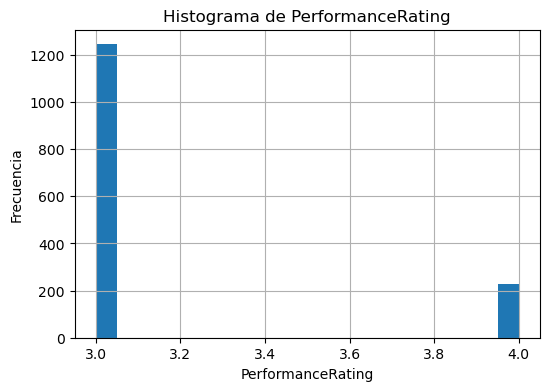

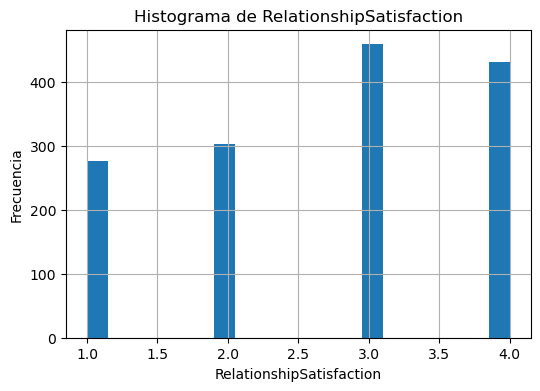

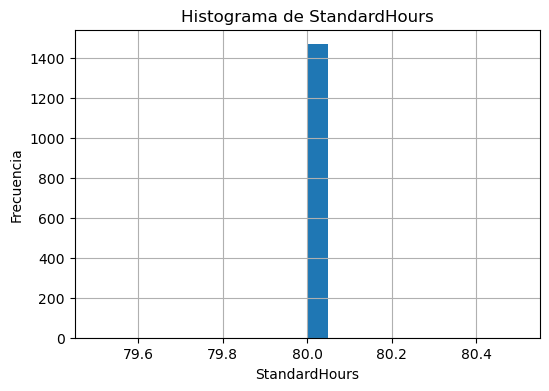

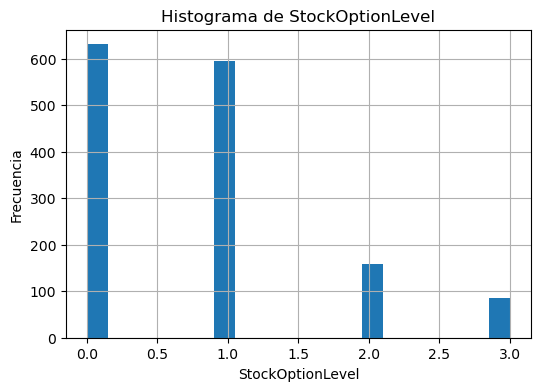

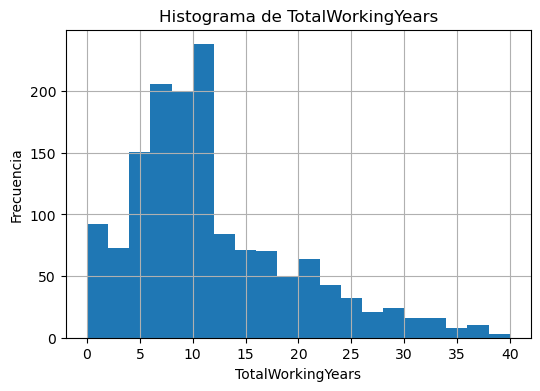

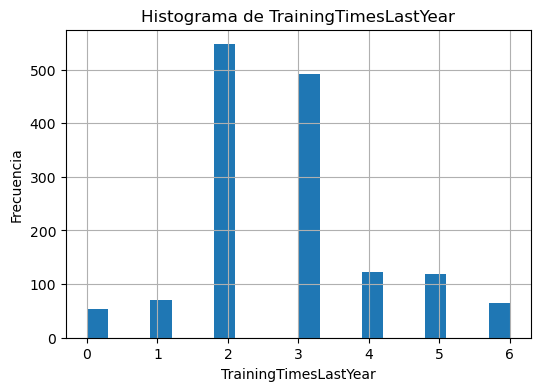

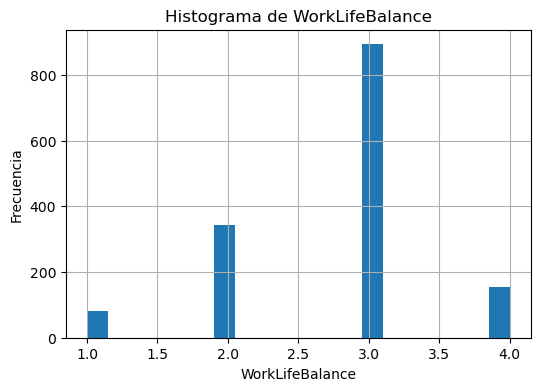

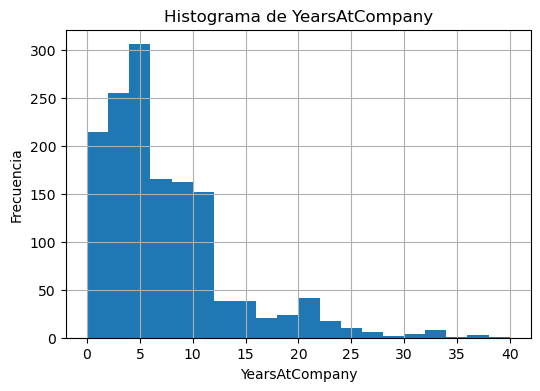

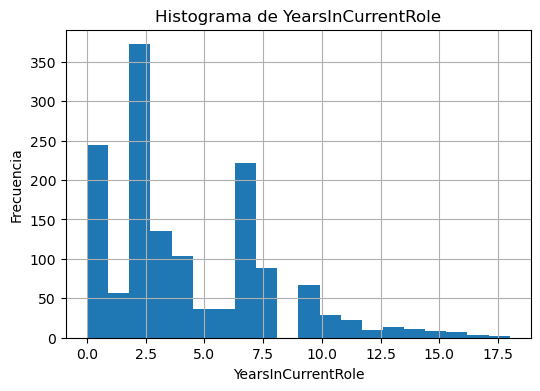

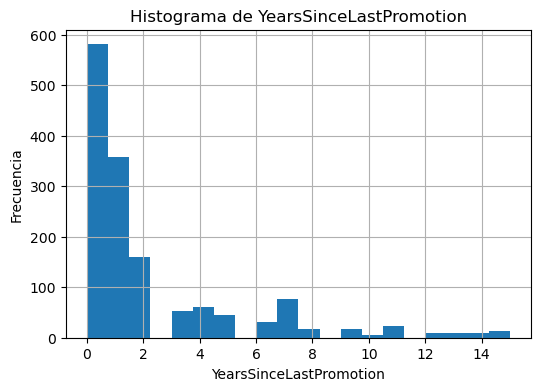

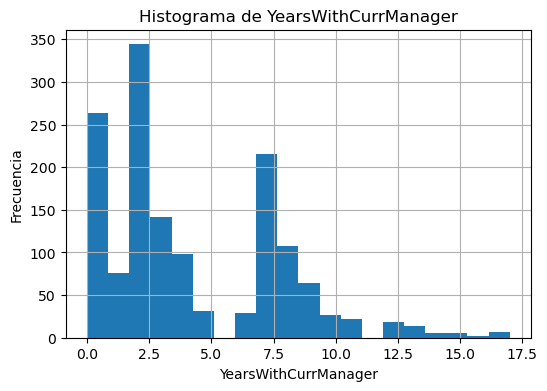

In [147]:
for col in num_cols:
    
    plt.figure(figsize=(6,4))
    
    df[col].hist(bins=20)
    
    plt.title(f"Histograma de {col}")
    plt.xlabel(col)
    plt.ylabel("Frecuencia")
    
    plt.show()

Interpretación: El perfil de los trabajadores, es un perfil medianamente privilegiado en cuanto a años de educación, tipo de profesión y salario mensual. La satisfacción con el empleo es positiva y en general los indicadores laborales, mantneiendo una antiguedad laboral media y colaboradores mayoritariamente adultos jovenes.

### Formulación del Modelo

Formule un modelo predictivo en donde se busca predecir la rotación de trabajadores utilizando variables demográficas, laborales y de desempeño. 

In [148]:
df["Attrition"].value_counts(normalize=True)

Attrition
No     0.838776
Yes    0.161224
Name: proportion, dtype: float64

### Preparación Modelo

In [149]:
# Target
df["Attrition"] = df["Attrition"].map({
    "No": 0,
    "Yes": 1
})

# Variable objetivo
y = df["Attrition"]

# Variables predictoras
X = df.drop(
    columns=[
        "Attrition",
        "EmployeeNumber"
    ]
)

# Dummies solo para categóricas
cat_cols = X.select_dtypes(include="object").columns

X = pd.get_dummies(
    X,
    columns=cat_cols,
    drop_first=True,
    dtype=int
)

# Revisar resultado
print(X.shape)
print(X.head())

(1470, 46)
   Age  DailyRate  DistanceFromHome  Education  EmployeeCount  \
0   41       1102                 1          2              1   
1   49        279                 8          1              1   
2   37       1373                 2          2              1   
3   33       1392                 3          4              1   
4   27        591                 2          1              1   

   EnvironmentSatisfaction  HourlyRate  JobInvolvement  JobLevel  \
0                        2          94               3         2   
1                        3          61               2         2   
2                        4          92               2         1   
3                        4          56               3         1   
4                        1          40               3         1   

   JobSatisfaction  ...  JobRole_Laboratory Technician  JobRole_Manager  \
0                4  ...                              0                0   
1                2  ...                

### Train Test Split

In [150]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.33,
    random_state=42,
    stratify=y
)

In [151]:
print(y.head())

print("\n")

print(y.value_counts())

0    1
1    0
2    1
3    0
4    0
Name: Attrition, dtype: int64


Attrition
0    1233
1     237
Name: count, dtype: int64


In [152]:
print(y_train.value_counts(normalize=True))

print("\n")

print(y_test.value_counts(normalize=True))

Attrition
0    0.838415
1    0.161585
Name: proportion, dtype: float64


Attrition
0    0.839506
1    0.160494
Name: proportion, dtype: float64


### Estandarización

In [153]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### Resultados Modelo

In [154]:
import joblib

joblib.dump(X_train_scaled,
            "../artifacts/X_train_scaled.pkl")

joblib.dump(X_test_scaled,
            "../artifacts/X_test_scaled.pkl")

joblib.dump(y_train,
            "../artifacts/y_train.pkl")

joblib.dump(y_test,
            "../artifacts/y_test.pkl")
# NUEVO
joblib.dump(X.columns,
            "../artifacts/feature_names.pkl")

['../artifacts/feature_names.pkl']